In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df=pd.read_csv("Sales_Data_Cleaned")

In [2]:
df["Date"] = pd.to_datetime(df["Date"])
df["MonthName"]=df["Date"].dt.month_name()
df["Revenue"] = df["Quantity"] * df["Price"]
df

,Order_ID,Date,Product,Category,Quantity,Price,City,OrderYear,OrderMonth,OrderDay,MonthName,Revenue
0,1001,2026-01-11,Mobile,Electronics,3.0,42750.0,Lahore,2026,1,11,January,128250.0
1,1002,2026-01-31,Headphones,Electronics,5.0,6175.0,Peshawar,2026,1,31,January,30875.0
2,1003,2026-01-13,Printer,Office,1.0,26600.0,Lahore,2026,1,13,January,26600.0
3,1004,2026-05-14,Keyboard,Accessories,5.0,4275.0,Peshawar,2026,5,14,May,21375.0
4,1005,2026-06-20,Keyboard,Accessories,5.0,4500.0,Lahore,2026,6,20,June,22500.0
5,1006,2026-06-04,Notebook,Stationery,3.0,475.0,Lahore,2026,6,4,June,1425.0
6,1007,2026-04-02,Printer,Office,3.0,26600.0,Lahore,2026,4,2,April,79800.0
7,1008,2026-01-31,Monitor,Electronics,3.0,32000.0,Islamabad,2026,1,31,January,96000.0
8,1009,2026-04-03,Monitor,Electronics,5.0,32000.0,Islamabad,2026,4,3,April,160000.0
9,1010,2026-05-22,Notebook,Stationery,1.0,500.0,Islamabad,2026,5,22,May,500.0


### Part 1 — Bar Chart

Q1 — Revenue by Product

In [3]:
Product_revenue=df.groupby("Product")["Revenue"].sum()
print(Product_revenue)

Product
Headphones      89700.0
Keyboard       163575.0
Laptop        1011500.0
Mobile        1759500.0
Monitor        612800.0
Mouse           29625.0
Notebook        17925.0
Printer        495600.0
Name: Revenue, dtype: float64


In [4]:
Product_revenue_summary=df.groupby("Product").agg(
    Product_revenue=("Revenue","sum")
)

Product_revenue_summary

,Product_revenue
Product,
Headphones,89700.0
Keyboard,163575.0
Laptop,1011500.0
Mobile,1759500.0
Monitor,612800.0
Mouse,29625.0
Notebook,17925.0
Printer,495600.0


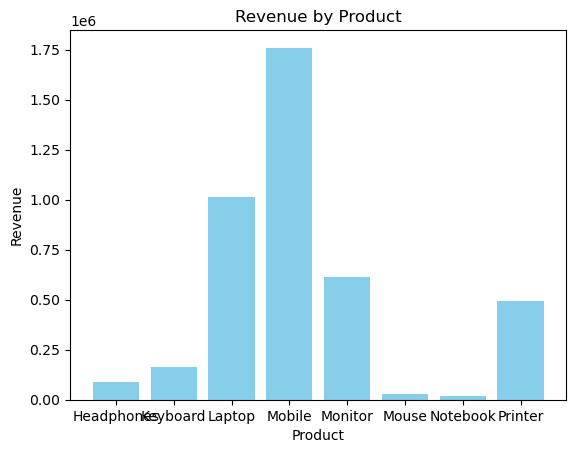

In [5]:
plt.bar(Product_revenue.index,Product_revenue.values,
       color="skyblue")

plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.show()

### Part 2 — Horizontal Bar Chart

Q2 — Revenue by City

In [6]:
revenue_bycity=df.groupby("City")["Revenue"].sum()
revenue_bycity

City
Islamabad     1393625.0
Karachi        587800.0
Lahore         590875.0
Multan         730325.0
Peshawar       387075.0
Rawalpindi     490525.0
Name: Revenue, dtype: float64

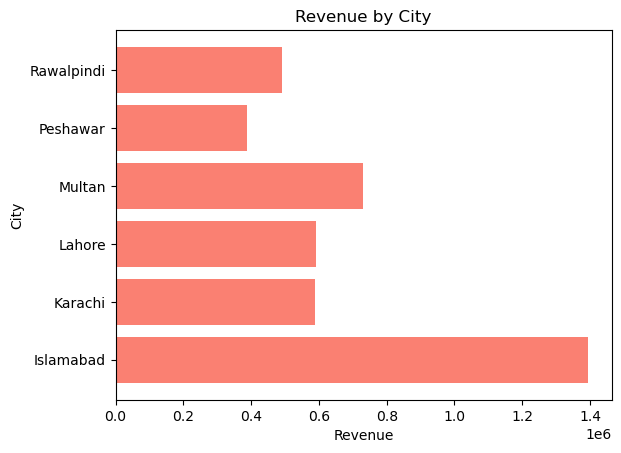

In [7]:
plt.barh(revenue_bycity.index,revenue_bycity.values,color="salmon")

plt.title("Revenue by City")
plt.xlabel("Revenue")
plt.ylabel("City")

plt.show()

Islamabad generated the highest total revenue among the cities.

### Part 3 — Line Chart

Q3 — Monthly Revenue

In [8]:
monthly_revenue=df.groupby("MonthName")["Revenue"].sum()
monthly_revenue

MonthName
April       978225.0
February    491400.0
January     877900.0
June        880450.0
March       649650.0
May         302600.0
Name: Revenue, dtype: float64

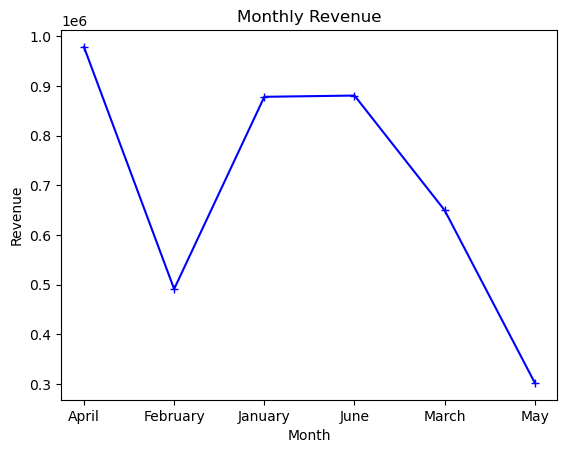

In [9]:
plt.plot(monthly_revenue.index,monthly_revenue.values,marker="+",linestyle="solid",color="blue")

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

Above plot shows that April has the max revenue as compared to other months.

### Part 4 — Histogram

Q4 — Distribution of Order Revenue

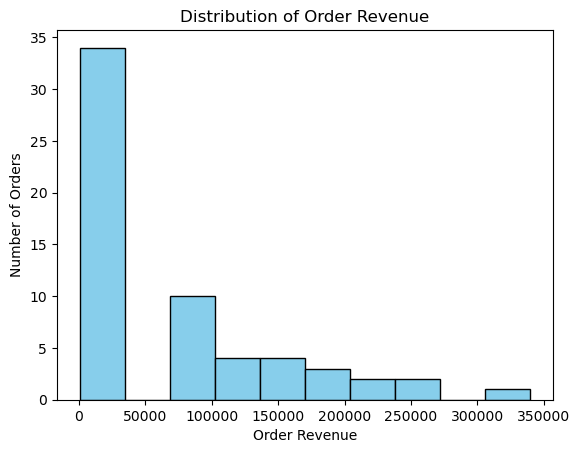

In [10]:
plt.hist(df["Revenue"],bins=10,color='skyblue', edgecolor='black')

plt.title("Distribution of Order Revenue")
plt.xlabel("Order Revenue")
plt.ylabel("Number of Orders")

plt.show()

The Ditribution of revenue is Rightward skewed.

### Part 5 — Scatter Plot

Q5 — Quantity vs Revenue

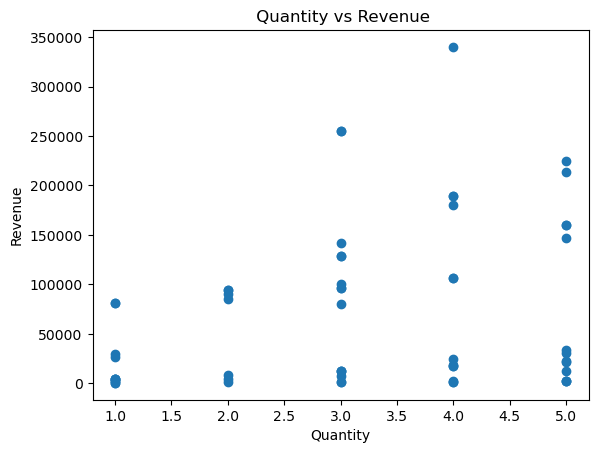

In [11]:
plt.scatter(df["Quantity"],df["Revenue"])
plt.title(" Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")

plt.show()

"The scatter plot does not show a strong or consistent linear relationship between quantity sold and revenue. Revenue also depends on the unit price of the product."

### Part 6 — Analyst Challenge

Choose one important finding from your EDA Day 2 project and visualize it.


The data shows that higher demand for products in a specific month does not relate to the monthly revenue.

Quantity Sold Vs Revenue

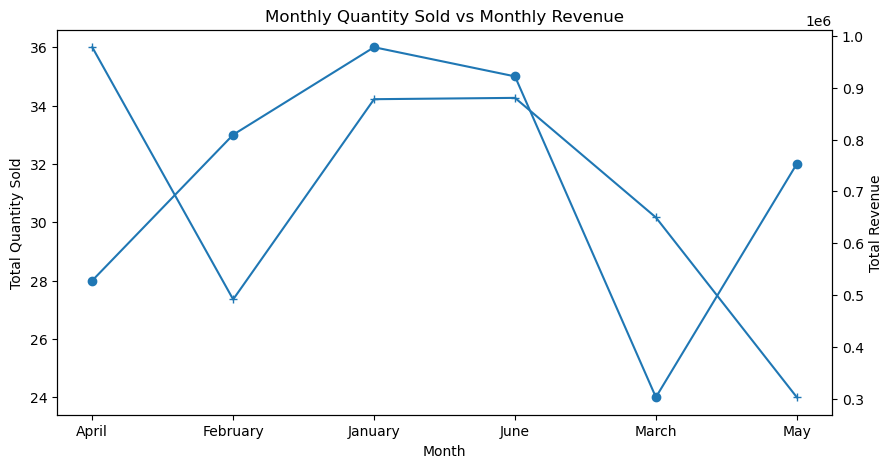

In [12]:
Monthly_Quantity=df.groupby("MonthName")["Quantity"].sum()
Monthly_Revenue=df.groupby("MonthName")["Revenue"].sum()

fig, ax1 = plt.subplots(figsize=(10, 5))

# Quantity
ax1.plot(
    Monthly_Quantity.index,
    Monthly_Quantity.values,
    marker="o",
    label="Quantity Sold"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Total Quantity Sold")

# Revenue
ax2 = ax1.twinx()

ax2.plot(
    Monthly_Revenue.index,
    Monthly_Revenue.values,
    marker="+",
    label="Revenue"
)

ax2.set_ylabel("Total Revenue")

plt.title("Monthly Quantity Sold vs Monthly Revenue")
plt.xticks(rotation=45)
plt.show()

"The chart shows that the month with the highest quantity sold is different from the month with the highest revenue. This indicates that sales volume alone does not determine monthly revenue; product prices and product mix also influence revenue."